### Libraries

In [1]:
import os
import numpy as np
import nibabel as nb
import pandas as pd
import glob
import matplotlib.pyplot as plt
import enigmatoolbox
#reload(enigmatoolbox)
#import enigmatoolbox
from enigmatoolbox.plotting import plot_cortical
from enigmatoolbox.utils.parcellation import parcel_to_surface
from enigmatoolbox.utils.parcellation import surface_to_parcel
from enigmatoolbox.datasets import load_sc, load_fc
from nilearn import plotting
from brainspace.mesh.mesh_io import read_surface
from brainspace.plotting import plot_hemispheres
from brainspace.gradient import GradientMaps
from brainspace.mesh.array_operations import smooth_array
from brainstat.datasets import fetch_mask
from brainstat.stats.terms import FixedEffect
from brainstat.stats.SLM import SLM
from brainspace.datasets import load_mask
from brainspace.utils.parcellation import map_to_labels
import scipy.stats as stats
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
import scipy as sp
from neuromaps.datasets import fetch_fslr
from surfplot import Plot
from brainspace.datasets import load_parcellation
import networkx as nx
from igraph import Graph
import copy
import cmocean
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from brainspace.null_models import SpinPermutations
from scipy.stats import spearmanr
from scipy.stats import pearsonr

### Load surfaces and masks

In [2]:
# Set dataset PNI as working directory
os.chdir('/data_/mica3/BIDS_PNI/derivatives/micapipe_v0.2.0')

# Path to MICAPIPE surf = mask_5k !
micapipe=os.popen("echo $MICAPIPE").read()[:-1]

# Load fsLR 32k
f32k_lh = read_surface(micapipe + '/surfaces/fsLR-32k.L.surf.gii', itype='gii')
f32k_rh = read_surface(micapipe + '/surfaces/fsLR-32k.R.surf.gii', itype='gii')

# Load native mid surface
inf_lh = read_surface(micapipe + '/surfaces/fsLR-5k.L.inflated.surf.gii', itype='gii')
inf_rh = read_surface(micapipe + '/surfaces/fsLR-5k.R.inflated.surf.gii', itype='gii')

mask_lh =  nb.load(micapipe + '/surfaces/fsLR-5k.R.mask.shape.gii').darrays[0].data
mask_rh =  nb.load(micapipe + '/surfaces/fsLR-5k.L.mask.shape.gii').darrays[0].data
mask_5k = np.concatenate((mask_lh, mask_rh), axis=0)

f5k_lh = read_surface(micapipe + '/surfaces/fsLR-5k.L.surf.gii', itype='gii')
f5k_rh = read_surface(micapipe + '/surfaces/fsLR-5k.R.surf.gii', itype='gii')

# Load fsLR masks
mask_32k = load_mask(join=True)

## Spin permutations functional connectivity ~ SWM feature

In [155]:
# Shape of the fsLR-5k matrices
N32k = 64984

# Load spheres fsLR5k
sphere_lh = read_surface(micapipe+'/surfaces/fsLR-32k.L.sphere.surf.gii', itype='gii')
sphere_rh = read_surface(micapipe+'/surfaces/fsLR-32k.R.sphere.surf.gii', itype='gii')

# Let's create some rotations
n_rand = 1000

spinp = SpinPermutations(n_rep=n_rand, random_state=0)
spinp.fit(sphere_lh, points_rh=sphere_rh)

SpinPermutations(n_rep=1000, random_state=0)

In [225]:
def plot_spin_permutations(sub_id, qmri):
    # Load curvature data (left & right hemispheres)
    #ffile_path = glob.glob(f"/data/mica3/BIDS_PNI/derivatives/micapipe_v0.2.0/sub-PNC0{sub_id}/ses-03/func/desc-me_task-rest_bold/surf/*_surf-fsLR-32k_atlas-schaefer-400_desc-FC.shape.gii")[0]
    ffile_path = glob.glob(f"/data/mica3/BIDS_PNI/derivatives/micapipe_v0.2.0/sub-PNC0{sub_id}/ses-03/func/desc-me_task-rest_bold/surf/*_atlas-schaefer-400_desc-FC.shape.gii")[0]
    fdata = nb.load(ffile_path).darrays[0].data
    
    fc_sym = np.triu(fdata,1)+fdata.T
    # Consider the absolute value
    fc_abs = np.abs(fc_sym)
    # Compute weighted degree centrality measures from the connectivity data
    fc_ctx = np.sum(fc_abs[49:,49:], axis=0) 
    # Map parcellated data to the surface
    fc_ctx_dc = parcel_to_surface(fc_ctx, 'schaefer_400_conte69')

    fdata_L = fc_ctx_dc[0:int(N32k/2)]
    fdata_R = fc_ctx_dc[int(N32k/2):N32k]

    # Load SWM intensity profile data
    sfile_path = glob.glob(f"sub-PNC0{sub_id}/ses-03/mpc-swm/acq-{qmri}/*_atlas-schaefer-400_desc-intensity_profiles.shape.gii")[0]
    swm_data = nb.load(sfile_path).darrays[0].data
    swm_noMW = np.delete(swm_data, [0, 201], axis=1)
    
    # Get the SWM values from 1mm below WM
    swm_1mm = swm_noMW[5, :]
    swm_2mm = swm_noMW[10, :]
    swm_3mm = swm_noMW[15, :]
    swm_1mm_dc = parcel_to_surface(swm_1mm, 'schaefer_400_conte69')
    swm_2mm_dc = parcel_to_surface(swm_2mm, 'schaefer_400_conte69')
    swm_3mm_dc = parcel_to_surface(swm_3mm, 'schaefer_400_conte69')
    print()
    # Spin permutation on full data (Get the rotated data)
    func_rotated = np.hstack(spinp.randomize(fdata_L, fdata_R))
    
    swms = {'SWM 1mm': swm_1mm_dc, 'SWM 2mm': swm_2mm_dc, 'SWM 3mm': swm_3mm_dc}
    
    # Plotting
    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    
    for k, (fn, swm) in enumerate(swms.items()):

        mask_bin = ~np.isnan(fc_ctx_dc) & ~np.isnan(swm)
        mask = mask_bin != 0

        non_zero_mask = ~((fc_ctx_dc[mask] == 0) & (swm[mask] == 0))
        valid_fc = fc_ctx_dc[non_zero_mask]
        valid_swm = swm[non_zero_mask]
        
        # Observed correlation
        r_obs, p_obs = spearmanr(valid_fc, valid_swm)
        
        # Permutation-based correlations
        r_spin = np.array([spearmanr(perm[mask][non_zero_mask], valid_swm)[0] for perm in func_rotated])
        p_spin = np.mean(np.abs(r_spin) >= np.abs(r_obs))
        
        # Plot null distribution
        axs[k].hist(r_spin, bins=25, density=True, alpha=0.5, color=(.6, .6, .6))
        axs[k].axvline(r_obs, lw=2, ls='--', color='k')
        axs[k].set_xlabel(f'Correlation with {fn}')
        if k == 0:
            axs[k].set_ylabel('Density')
        #textstr = f'Obs: r = {r_obs:.3f}, p = {p_obs:.3f}\nSpin: r = {np.mean(r_spin):.3f}, p = {p_spin:.3f}'
        textstr = f"r = {r_obs:.3f}, $P_{{spin}}$ = {p_spin:.3f}"
        axs[k].text(0.95, 0.95, textstr, transform=axs[k].transAxes, fontsize=12,
                    verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round,pad=0.3', edgecolor='gray', facecolor='white'))
    
    fig.tight_layout()
    plt.show()

[2.07038784 2.01975918 1.83636403 ... 2.03524542 2.03524542 2.03524542]


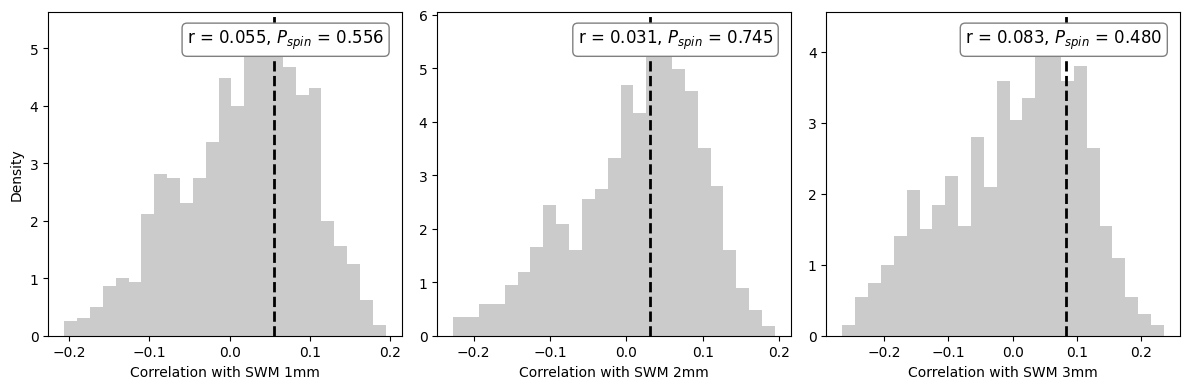

In [226]:
plot_spin_permutations(sub_id="22", qmri="MTSAT_protocol")

In [543]:
def plot_func_swm_correlation(sub_id, qmri):
    try:
        ffile_path = glob.glob(f"/data/mica3/BIDS_PNI/derivatives/micapipe_v0.2.0/sub-PNC0{sub_id}/ses-03/func/desc-me_task-rest_bold/surf/*_atlas-schaefer-400_desc-FC.shape.gii")[0]
        fdata = nb.load(ffile_path).darrays[0].data

        fc_sym = np.triu(fdata,1)+fdata.T
        # Consider the absolute value
        fc_abs = np.abs(fc_sym)
        # Compute weighted degree centrality measures from the connectivity data
        fc_ctx = np.sum(fc_abs[49:,49:], axis=0) 
        # Map parcellated data to the surface
        fc_ctx_dc = parcel_to_surface(fc_ctx, 'schaefer_400_conte69')
        
        # Load SWM intensity profile data
        sfile_path = glob.glob(f"sub-PNC0{sub_id}/ses-03/mpc-swm/acq-{qmri}/*_atlas-schaefer-400_desc-intensity_profiles.shape.gii")[0]
        swm_data = nb.load(sfile_path).darrays[0].data
        swm_noMW = np.delete(swm_data, [0, 201], axis=1)

        swm = swm_data[5, :]  # 특정 depth 선택 (예: 5mm)
        # Get the SWM values from 1mm below WM
        swm_1mm = swm_noMW[5, :]
        swm_2mm = swm_noMW[10, :]
        swm_3mm = swm_noMW[15, :]
        swm_1mm_dc = parcel_to_surface(swm_1mm, 'schaefer_400_conte69')
        swm_2mm_dc = parcel_to_surface(swm_2mm, 'schaefer_400_conte69')
        swm_3mm_dc = parcel_to_surface(swm_3mm, 'schaefer_400_conte69')
        
        swms = {'SWM 1mm': swm_1mm_dc, 'SWM 2mm': swm_2mm_dc, 'SWM 3mm': swm_3mm_dc}
        
        # Plotting
        fig, axs = plt.subplots(1, 3, figsize=(12, 4))

        for k, (fn, swm) in enumerate(swms.items()):
            mask_bin = ~np.isnan(fc_ctx_dc) & ~np.isnan(swm)
            mask = mask_bin != 0

            non_zero_mask = ~((fc_ctx_dc[mask] == 0) & (swm[mask] == 0))
            valid_fc = fc_ctx_dc[non_zero_mask]
            valid_swm = swm[non_zero_mask]
            
            r, p = sp.stats.spearmanr(valid_fc, valid_swm)

            df = pd.DataFrame({'Functional Strength': valid_fc, f'{qmri} intensity': valid_swm})
            sns.regplot(
                x='Functional Strength', y=f'{qmri} intensity', data=df, ax=axs[k],
                scatter_kws={'color': '#A9A9A9', 'alpha': 0.7},  # 밝은 회색
                line_kws={'color': '#5072A7', 'linewidth': 3}  # Royal Blue
            )
            #axs[k].set_title(f'{fn}\n$(r$ = {r:.2f}, $P_{{obs}}$ = {p:.3f})', fontsize=20)
            axs[k].set_title(f'FS vs. T1 map\n$(r$ = {r:.2f}, $P_{{obs}}$ = {p:.3f})', fontsize=20)
            axs[k].set_xlabel('Functional Strength', fontsize=16)
            axs[k].set_ylabel(f'{qmri} Intensity', fontsize=16)
            axs[k].grid(True, linestyle='--', linewidth=0.5)

        plt.tight_layout()
        plt.show()
    
    except Exception as e:
        print(f"Unexpected error: {e}")


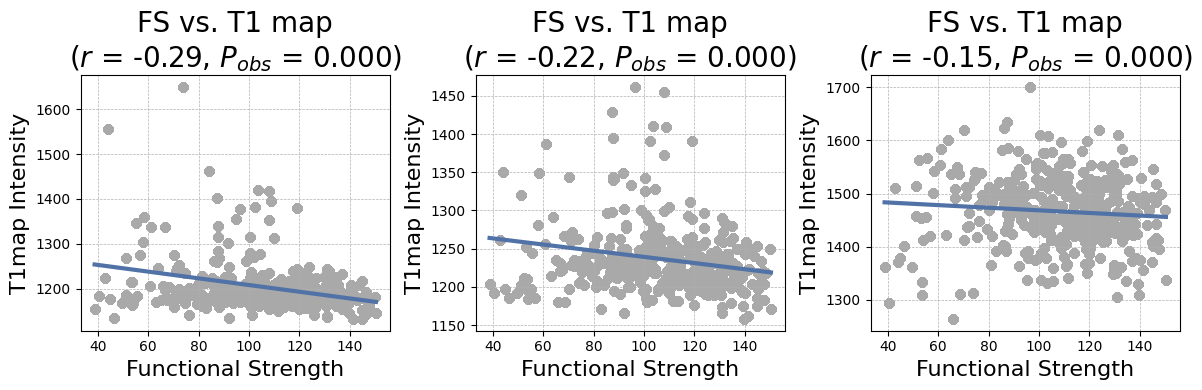

In [544]:
plot_func_swm_correlation(sub_id="03", qmri="T1map")

## Graph

In [164]:
def plot_swm_boxplot(swm_1mm, swm_2mm, swm_3mm, p_1mm, p_2mm, p_3mm, significant_color="blue", highlight_color="dodgerblue"):

    # Step 1: 데이터를 pandas DataFrame으로 변환 (long-form)
    df_1mm = pd.DataFrame({'Correlation': swm_1mm, 'Depth': 'SWM 1mm', 'P-value': p_1mm})
    df_2mm = pd.DataFrame({'Correlation': swm_2mm, 'Depth': 'SWM 2mm', 'P-value': p_2mm})
    df_3mm = pd.DataFrame({'Correlation': swm_3mm, 'Depth': 'SWM 3mm', 'P-value': p_3mm})

    # 데이터 결합
    df_all = pd.concat([df_1mm, df_2mm, df_3mm])

    # Step 2: 그래프 생성
    plt.figure(figsize=(11, 6))

    # 박스 플롯 생성 (흰색 박스)
    sns.boxplot(x='Depth', y='Correlation', data=df_all, linewidth=2, showfliers=False,
                hue='Depth', palette={'SWM 1mm': 'white', 'SWM 2mm': 'white', 'SWM 3mm': 'white'})

    # Step 3: 전체 데이터 평균값 계산 및 선으로 연결 (검은색)
    mean_all = {
        'SWM 1mm': np.mean(swm_1mm),
        'SWM 2mm': np.mean(swm_2mm),
        'SWM 3mm': np.mean(swm_3mm),
    }

    plt.plot(mean_all.keys(), mean_all.values(), marker='o', color='darkgrey', linewidth=3, markersize=10, zorder=15)

    # Step 4: 유의미한 값만 따로 평균값 계산 및 선으로 연결 (파란색)
    mean_significant = {}
    
    for depth, swm_values, p_values in zip(['SWM 1mm', 'SWM 2mm', 'SWM 3mm'],
                                           [swm_1mm, swm_2mm, swm_3mm],
                                           [p_1mm, p_2mm, p_3mm]):
        significant_values = np.array(swm_values)[np.array(p_values) < 0.05]  # 유의미한 값만 필터링
        if len(significant_values) > 0:  # 유의미한 값이 하나라도 있을 때만 평균 계산
            mean_significant[depth] = np.mean(significant_values)

    # 유의미한 평균값이 있는 경우만 선을 그림
    if mean_significant:
        plt.plot(mean_significant.keys(), mean_significant.values(), marker='o', 
                 color=highlight_color, linewidth=3, markersize=10, zorder=16)

    # Step 5: 데이터 포인트 추가
    depth_labels = ['SWM 1mm', 'SWM 2mm', 'SWM 3mm']
    depth_indices = {label: i for i, label in enumerate(depth_labels)}

    for depth, swm_values, p_values in zip(depth_labels, [swm_1mm, swm_2mm, swm_3mm], [p_1mm, p_2mm, p_3mm]):

        depth_idx = depth_indices[depth]

        significant_mask = np.array(p_values) < 0.05
        nonsignificant_values = np.array(swm_values)[~significant_mask]

        # (1) 유의미하지 않은 점 (lightgray)
        if len(nonsignificant_values) > 0:
            x_jitter_nonsignificant = depth_idx + np.random.uniform(-0.1, 0.1, len(nonsignificant_values))
            plt.scatter(x_jitter_nonsignificant, nonsignificant_values, color='lightgray', s=80, alpha=0.7, zorder=10)

        # (2) 유의미한 점 (significant_color)
        if np.any(significant_mask):
            x_jitter_significant = depth_idx + np.random.uniform(-0.1, 0.1, np.sum(significant_mask))
            plt.scatter(x_jitter_significant, np.array(swm_values)[significant_mask], 
                        color=significant_color, s=80, alpha=0.8, zorder=11)

    # X축 설정
    plt.xticks(ticks=range(len(depth_labels)), labels=depth_labels)

    # Step 6: y축 0인 부분의 눈금선 추가
    plt.axhline(0, color='black', linestyle='--', linewidth=3)

    # Step 7: 그래프 설정
    plt.xlabel('', fontsize=20)
    plt.ylabel('Correlation Coefficient (r)', fontsize=20)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.grid(True)
    plt.ylim(-0.35, 0.35)

    # 범례 추가
    from matplotlib.lines import Line2D

    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=significant_color, markersize=10, label=r'$P_{spin} < 0.05$', markeredgewidth=1),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgray', markersize=10, label=r'$P_{spin} \geq 0.05$', markeredgewidth=1),
        Line2D([0], [0], marker='o', color=highlight_color, markersize=10, label=r'Significant Mean', markeredgewidth=1),
        Line2D([0], [0], marker='o', color='darkgrey', markersize=10, label=r'Overall Mean', markeredgewidth=1)
    ]

    #plt.legend(handles=legend_elements, loc='upper left', fontsize=20, handletextpad=0.3)
    plt.legend(handles=legend_elements, loc='lower left', fontsize=20, handletextpad=0.3, bbox_to_anchor=(1, 0), borderpad=1)

    # 그래프 보여주기
    plt.tight_layout()
    plt.show()


### T1map

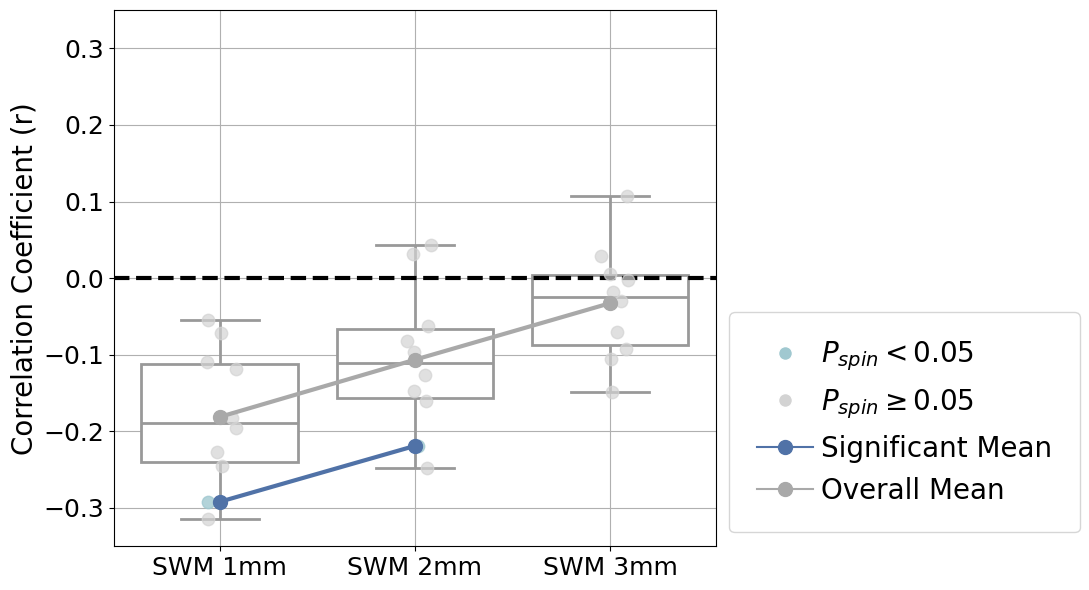

In [165]:
swm_1mm = [-0.292, -0.315, -0.196, -0.118, -0.245, -0.11, -0.072, -0.183, -0.227, -0.054]
swm_2mm = [-0.219, -0.248, -0.126, -0.082, -0.16, -0.062, 0.043, -0.096, -0.147, 0.032]
swm_3mm = [-0.149, -0.093, -0.106, -0.018, -0.003, -0.03, 0.029, 0.006, -0.07, 0.107]
p_1mm = [0.016, 0.059, 0.387, 0.36, 0.112, 0.515, 0.344, 0.086, 0.054, 0.712]
p_2mm = [0.025, 0.184, 0.576, 0.443, 0.271, 0.71, 0.575, 0.35, 0.256, 0.783]
p_3mm = [0.106, 0.539, 0.538, 0.846, 0.98, 0.789, 0.767, 0.951, 0.645, 0.257]

plot_swm_boxplot(swm_1mm, swm_2mm, swm_3mm, p_1mm, p_2mm, p_3mm, significant_color="#A0C8D0", highlight_color="#5072A7")

### MTSAT

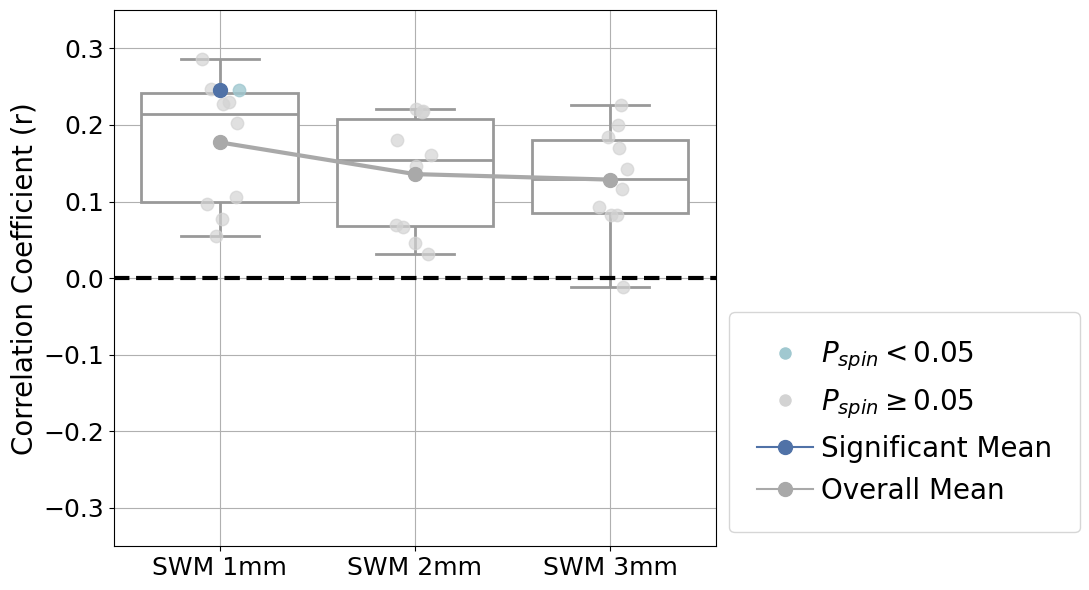

In [166]:
swm_1mm = [0.286, 0.106, 0.247, 0.23, 0.246, 0.097, 0.077, 0.227, 0.202, 0.055]
swm_2mm = [0.217, 0.067, 0.218, 0.221, 0.18, 0.07, 0.046, 0.147, 0.161, 0.031]
swm_3mm = [0.2, 0.17, 0.184, 0.226, 0.142, -0.011, 0.093, 0.117, 0.082, 0.083]
p_1mm = [0.106, 0.625, 0.288, 0.239, 0.035, 0.719, 0.686, 0.147, 0.483, 0.556]
p_2mm = [0.249, 0.726, 0.346, 0.175, 0.157, 0.779, 0.78, 0.292, 0.519, 0.745]
p_3mm = [0.229, 0.261, 0.36, 0.087, 0.373, 0.955, 0.374, 0.268, 0.53, 0.48]

plot_swm_boxplot(swm_1mm, swm_2mm, swm_3mm, p_1mm, p_2mm, p_3mm, significant_color="#A0C8D0", highlight_color="#5072A7")

## Mean value (group study)

### Load intensity profiles

In [236]:
fc_ctx_10sub = np.load('/host/verges/tank/data/youngeun/myjupyter/array/fc_ctx_10sub.npy')
fc_schefer400_10sub = np.load('/host/verges/tank/data/youngeun/myjupyter/array/fc_schefer400_10sub.npy')

# Load GM intensity profiles
T1map_swm_int = np.flip(np.load('/host/verges/tank/data/youngeun/myjupyter/array/PNC-10sub_T1map_swmIP.npy'), axis=0)
T1map_swm_1mm = T1map_swm_int[5,:]
T1map_swm_2mm = T1map_swm_int[10,:]
T1map_swm_3mm = T1map_swm_int[15,:]

# Load GM intensity profiles
MTSAT_swm_int = np.flip(np.load('/host/verges/tank/data/youngeun/myjupyter/array/PNC-10sub_MTsat_swmIP.npy'), axis=0)
MTSAT_swm_1mm = MTSAT_swm_int[5,:]
MTSAT_swm_2mm = MTSAT_swm_int[10,:]
MTSAT_swm_3mm = MTSAT_swm_int[15,:]

In [111]:
# Subject IDs 및 qMRI 설정
sub_ids = ["03", "06", "07", "09", "10", "15", "16", "18", "19", "22"]
qmri = "MTSAT_protocol"

In [112]:
# 데이터를 저장할 리스트
swm_stack = []

for sub_id in sub_ids:

    sfile_path = glob.glob(f"sub-PNC0{sub_id}/ses-03/mpc-swm/acq-{qmri}/*_atlas-schaefer-400_desc-intensity_profiles.shape.gii")
    swm_data = nb.load(sfile_path[0]).darrays[0].data
    swm_noMW = np.delete(swm_data, [0, 201], axis=1)

    swm_stack.append(swm_noMW)

#swm_stack = np.stack(swm_stack, axis=0)
MTSAT_schaefer400_10sub = np.mean(swm_stack, axis=0)

In [115]:
T1map_schaefer400_swm1mm = parcel_to_surface(T1map_schaefer400_10sub[5,:], 'schaefer_400_conte69')
T1map_schaefer400_swm2mm = parcel_to_surface(T1map_schaefer400_10sub[10,:], 'schaefer_400_conte69')
T1map_schaefer400_swm3mm = parcel_to_surface(T1map_schaefer400_10sub[15,:], 'schaefer_400_conte69')

MTSAT_schaefer400_swm1mm = parcel_to_surface(MTSAT_schaefer400_10sub[5,:], 'schaefer_400_conte69')
MTSAT_schaefer400_swm2mm = parcel_to_surface(MTSAT_schaefer400_10sub[10,:], 'schaefer_400_conte69')
MTSAT_schaefer400_swm3mm = parcel_to_surface(MTSAT_schaefer400_10sub[15,:], 'schaefer_400_conte69')

In [41]:
# Shape of the fsLR-5k matrices
#N32k = 9684
N32k = 64984

# Load spheres fsLR5k
sphere_lh = read_surface(micapipe+'/surfaces/fsLR-32k.L.sphere.surf.gii', itype='gii')
sphere_rh = read_surface(micapipe+'/surfaces/fsLR-32k.R.sphere.surf.gii', itype='gii')

# Let's create some rotations
n_rand = 1000

spinp = SpinPermutations(n_rep=n_rand, random_state=0)
spinp.fit(sphere_lh, points_rh=sphere_rh)

SpinPermutations(n_rep=1000, random_state=0)

In [216]:
print(fc_schefer400_10sub)
print(T1map_schaefer400_swm1mm)

[87.12982941 62.82134628 52.99396515 ... 42.52945328 42.52945328
 42.52945328]
[1209.40283203 1178.95239258 1207.37072754 ... 1190.05993652 1190.05993652
 1190.05993652]


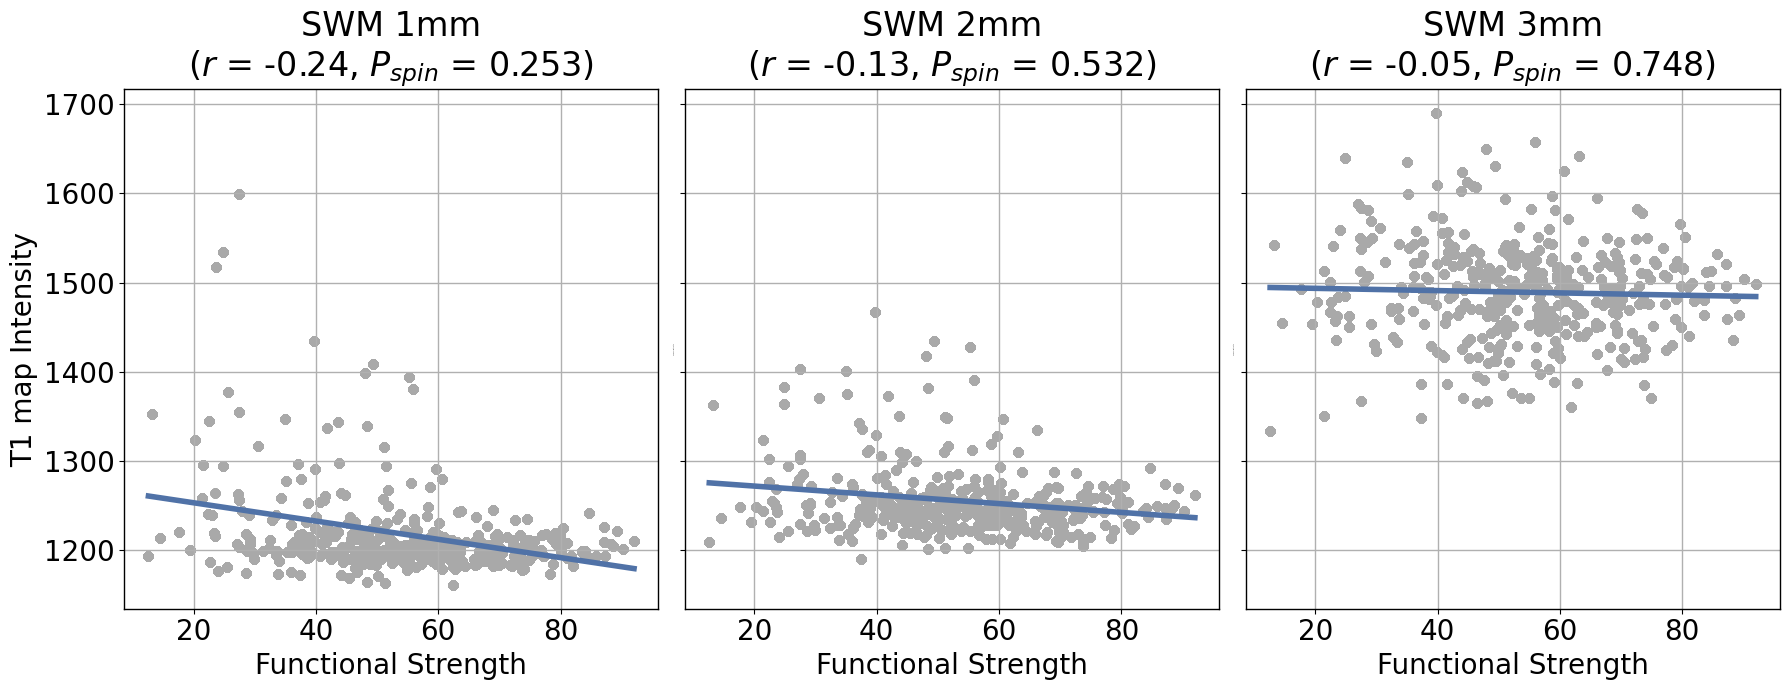

In [242]:
# List of mod2 datasets and their titles
#qmri_list = [T1map_swm_1mm, T1map_swm_2mm, T1map_swm_3mm]
qmri_list = [T1map_schaefer400_swm1mm, T1map_schaefer400_swm2mm, T1map_schaefer400_swm3mm]
titles = ['SWM 1mm', 'SWM 2mm', 'SWM 3mm']

fdata_L = fc_schefer400_10sub[0:int(N32k/2)]
fdata_R = fc_schefer400_10sub[int(N32k/2):N32k]

# Spin permutation on full data (Get the rotated data)
func_rotated = np.hstack(spinp.randomize(fdata_L, fdata_R))

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharex=True, sharey=True)

# Loop through mod2 datasets and plot
for i, (qmri, title) in enumerate(zip(qmri_list, titles)):

    mask = ~np.isnan(fc_schefer400_10sub) & ~np.isnan(qmri)
    non_zero_mask = ~((fc_schefer400_10sub[mask] == 0) & (qmri[mask] == 0))
    valid_fc = fc_schefer400_10sub[mask][non_zero_mask]
    valid_swm = qmri[mask][non_zero_mask]

    # Observed correlation
    r_obs, p_obs = spearmanr(valid_fc, valid_swm)
    
    # Permutation-based correlations
    r_spin = np.array([spearmanr(perm[mask][non_zero_mask], valid_swm)[0] for perm in func_rotated])
    p_spin = np.mean(np.abs(r_spin) >= np.abs(r_obs))
    
    # Create DataFrame for seaborn
    df = pd.DataFrame({'FS': valid_fc, 'qMRI': valid_swm})

    # Scatter plot with linear regression
    sns.regplot(
        x='FS', y='qMRI', data=df, ax=axes[i],
        scatter_kws={'color': '#A9A9A9', 'alpha': 0.6}, line_kws={'color': '#5072A7', 'linewidth': 4}, ci=95
    )
    
    # Set labels and title
    axes[i].set_title(f'{title}\n$(r$ = {r_obs:.2f}, $P_{{spin}}$ = {p_spin:.3f})', fontsize=24)
    axes[i].set_xlabel('Functional Strength', fontsize=20)
    axes[i].set_ylabel('T1 map Intensity', fontsize=20 if i == 0 else 0)  # Only first subplot has y-label
    axes[i].tick_params(axis='both', labelsize=20)
    
    # Make outer grid lines thicker and set inner grid lines as thinner
    axes[i].grid(True, which='both', axis='both', linestyle='-', linewidth=1)  # Thin grid lines for the inner grid
    # Make outer borders thicker
    for spine in axes[i].spines.values():
        spine.set_linewidth(1)
        spine.set_edgecolor('black')

# Adjust layout
plt.tight_layout()
plt.show()

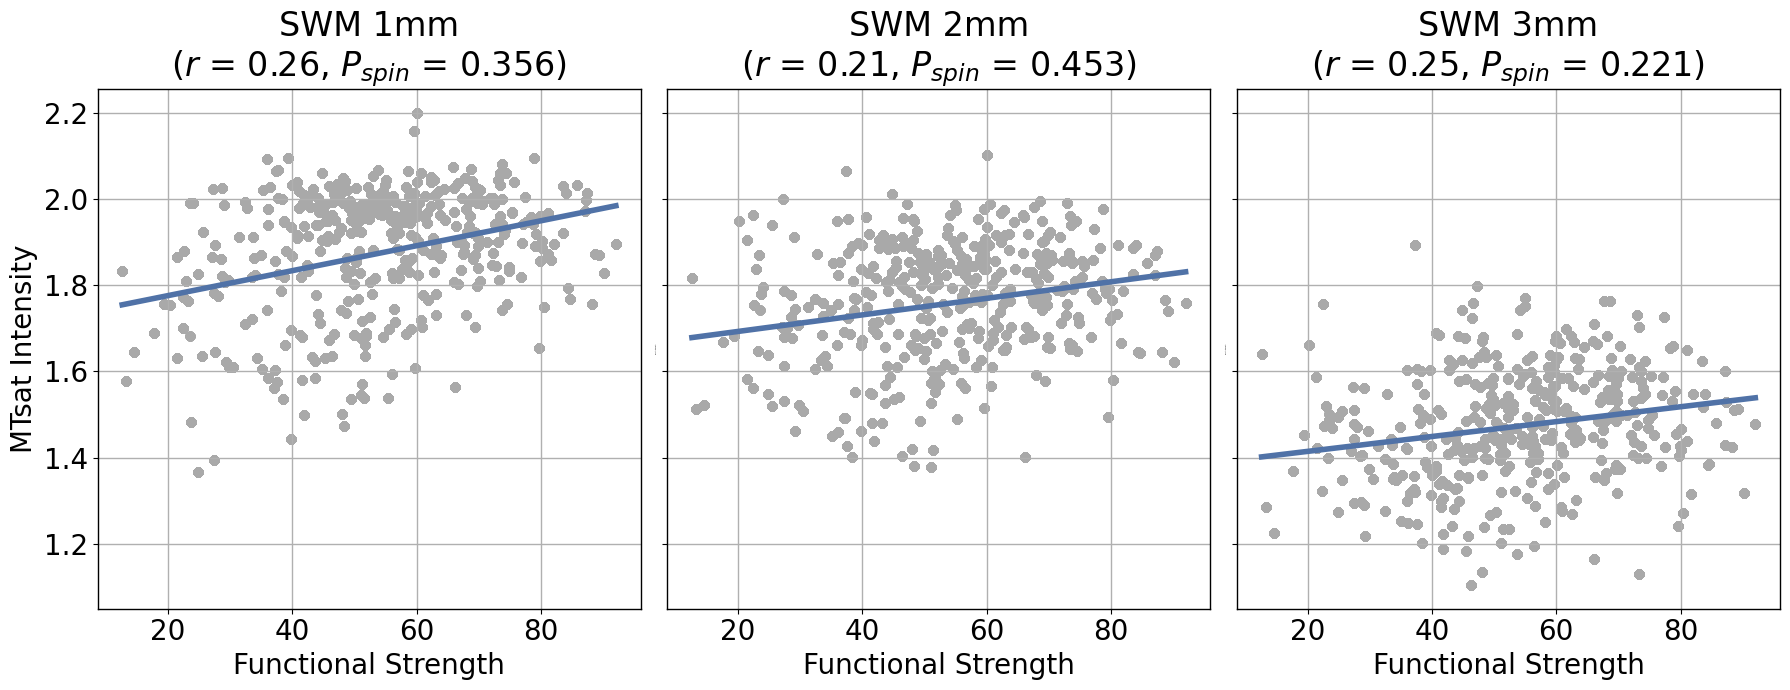

In [240]:
# List of mod2 datasets and their titles
#qmri_list = [T1map_swm_1mm, T1map_swm_2mm, T1map_swm_3mm]
qmri_list = [MTSAT_schaefer400_swm1mm, MTSAT_schaefer400_swm2mm, MTSAT_schaefer400_swm3mm]
titles = ['SWM 1mm', 'SWM 2mm', 'SWM 3mm']

fdata_L = fc_schefer400_10sub[0:int(N32k/2)]
fdata_R = fc_schefer400_10sub[int(N32k/2):N32k]

# Spin permutation on full data (Get the rotated data)
func_rotated = np.hstack(spinp.randomize(fdata_L, fdata_R))

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharex=True, sharey=True)

# Loop through mod2 datasets and plot
for i, (qmri, title) in enumerate(zip(qmri_list, titles)):

    mask_bin = ~np.isnan(fc_schefer400_10sub) & ~np.isnan(qmri)
    mask = mask_bin != 0

    non_zero_mask = ~((fc_schefer400_10sub[mask] == 0) & (qmri[mask] == 0))
    valid_fc = fc_schefer400_10sub[mask][non_zero_mask]
    valid_swm = qmri[mask][non_zero_mask]

    # Observed correlation
    r_obs, p_obs = spearmanr(valid_fc, valid_swm)
    
    # Permutation-based correlations
    r_spin = np.array([spearmanr(perm[mask][non_zero_mask], valid_swm)[0] for perm in func_rotated])
    p_spin = np.mean(np.abs(r_spin) >= np.abs(r_obs))
    
    # Create DataFrame for seaborn
    df = pd.DataFrame({'FS': valid_fc, 'qMRI': valid_swm})

    # Scatter plot with linear regression
    sns.regplot(
        x='FS', y='qMRI', data=df, ax=axes[i],
        scatter_kws={'color': '#A9A9A9', 'alpha': 0.6}, line_kws={'color': '#5072A7', 'linewidth': 4}, ci=95
    )
    
    # Set labels and title
    axes[i].set_title(f'{title}\n$(r$ = {r_obs:.2f}, $P_{{spin}}$ = {p_spin:.3f})', fontsize=24)
    axes[i].set_xlabel('Functional Strength', fontsize=20)
    axes[i].set_ylabel('MTsat Intensity', fontsize=20 if i == 0 else 0)  # Only first subplot has y-label
    axes[i].tick_params(axis='both', labelsize=20)
    
    # Make outer grid lines thicker and set inner grid lines as thinner
    axes[i].grid(True, which='both', axis='both', linestyle='-', linewidth=1)  # Thin grid lines for the inner grid
    # Make outer borders thicker
    for spine in axes[i].spines.values():
        spine.set_linewidth(1)
        spine.set_edgecolor('black')

# Adjust layout
plt.tight_layout()
plt.show()

## Spin permutations ReHo ~ SWM feature

In [308]:
# Shape of the fsLR-5k matrices
N32k = 64984

# Load spheres fsLR5k
sphere_lh = read_surface(micapipe+'/surfaces/fsLR-32k.L.sphere.surf.gii', itype='gii')
sphere_rh = read_surface(micapipe+'/surfaces/fsLR-32k.R.sphere.surf.gii', itype='gii')

# Let's create some rotations
n_rand = 1000

spinp = SpinPermutations(n_rep=n_rand, random_state=0)
spinp.fit(sphere_lh, points_rh=sphere_rh)

SpinPermutations(n_rep=1000, random_state=0)

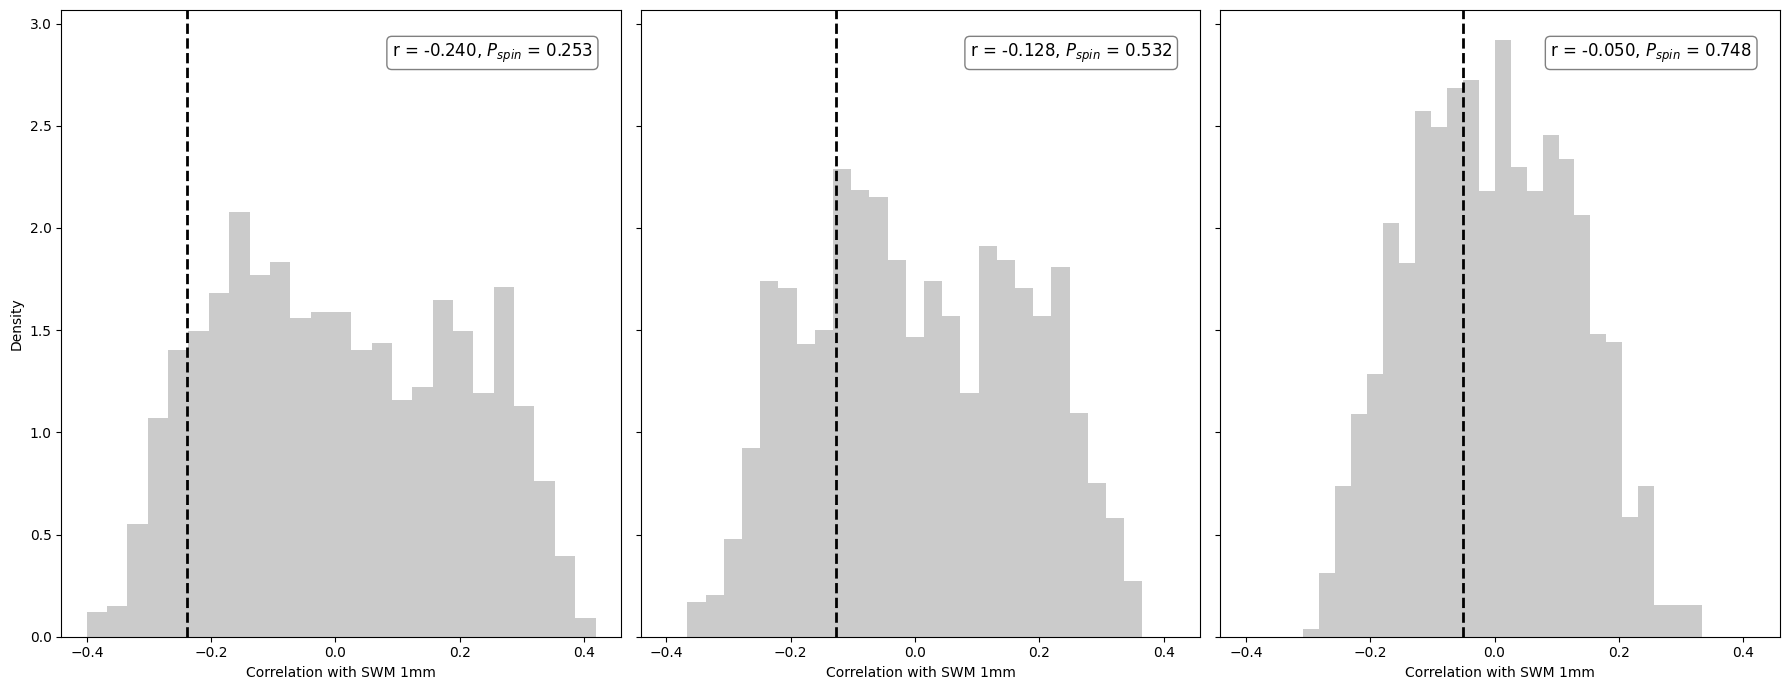

In [241]:
qmri_list = [T1map_schaefer400_swm1mm, T1map_schaefer400_swm2mm, T1map_schaefer400_swm3mm]
titles = ['SWM 1mm', 'SWM 2mm', 'SWM 3mm']

fdata_L = fc_schefer400_10sub[0:int(N32k/2)]
fdata_R = fc_schefer400_10sub[int(N32k/2):N32k]

# Spin permutation on full data (Get the rotated data)
func_rotated = np.hstack(spinp.randomize(fdata_L, fdata_R))

# Create subplots
fig, axs = plt.subplots(1, 3, figsize=(18, 7), sharex=True, sharey=True)

# Loop through mod2 datasets and plot
for k, (qmri, title) in enumerate(zip(qmri_list, titles)):

    mask_bin = ~np.isnan(fc_schefer400_10sub) & ~np.isnan(qmri)
    mask = mask_bin != 0

    non_zero_mask = ~((fc_schefer400_10sub[mask] == 0) & (qmri[mask] == 0))
    valid_fc = fc_schefer400_10sub[mask][non_zero_mask]
    valid_swm = qmri[mask][non_zero_mask]

    # Observed correlation
    r_obs, p_obs = spearmanr(valid_fc, valid_swm)
    
    # Permutation-based correlations
    r_spin = np.array([spearmanr(perm[mask][non_zero_mask], valid_swm)[0] for perm in func_rotated])
    p_spin = np.mean(np.abs(r_spin) >= np.abs(r_obs))
        
    # Plot null distribution
    axs[k].hist(r_spin, bins=25, density=True, alpha=0.5, color=(.6, .6, .6))
    axs[k].axvline(r_obs, lw=2, ls='--', color='k')
    axs[k].set_xlabel(f'Correlation with {fn}')
    if k == 0:
        axs[k].set_ylabel('Density')
    #textstr = f'Obs: r = {r_obs:.3f}, p = {p_obs:.3f}\nSpin: r = {np.mean(r_spin):.3f}, p = {p_spin:.3f}'
    textstr = f"r = {r_obs:.3f}, $P_{{spin}}$ = {p_spin:.3f}"
    axs[k].text(0.95, 0.95, textstr, transform=axs[k].transAxes, fontsize=12,
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round,pad=0.3', edgecolor='gray', facecolor='white'))

fig.tight_layout()
plt.show()

In [3]:
def plot_reho_swm_correlation(sub_id, qmri):
    try:
        # Combine left and right hemisphere data
        rfile = glob.glob(f"//host/verges/tank/data/youngeun/ReHo/neighbors1/fsLR32k_schaefer400/sub-PNC0{sub_id}_ses-03_surf-fsLR-32k_desc-ReHo.shape.gii")[0]
        reho = nb.load(rfile).darrays[0].data
        reho_sq = np.squeeze(reho)
    
        # Map parcellated data to the surface
        reho_dc = parcel_to_surface(reho_sq, 'schaefer_400_conte69')
    
        rdata_L = reho_dc[0:int(N32k/2)]
        rdata_R = reho_dc[int(N32k/2):N32k]
        
        # Load SWM intensity profile data
        sfile_path = glob.glob(f"sub-PNC0{sub_id}/ses-03/mpc-swm/acq-{qmri}/*_atlas-schaefer-400_desc-intensity_profiles.shape.gii")[0]
        swm_data = nb.load(sfile_path).darrays[0].data
        swm_noMW = np.delete(swm_data, [0, 201], axis=1)

        swm = swm_data[5, :]  # 특정 depth 선택 (예: 5mm)
        # Get the SWM values from 1mm below WM
        swm_1mm = swm_noMW[5, :]
        swm_2mm = swm_noMW[10, :]
        swm_3mm = swm_noMW[15, :]
        swm_1mm_dc = parcel_to_surface(swm_1mm, 'schaefer_400_conte69')
        swm_2mm_dc = parcel_to_surface(swm_2mm, 'schaefer_400_conte69')
        swm_3mm_dc = parcel_to_surface(swm_3mm, 'schaefer_400_conte69')
        
        swms = {'SWM 1mm': swm_1mm_dc, 'SWM 2mm': swm_2mm_dc, 'SWM 3mm': swm_3mm_dc}
        
        # Plotting
        fig, axs = plt.subplots(1, 3, figsize=(12, 4))

        for k, (fn, swm) in enumerate(swms.items()):
            mask_bin = ~np.isnan(reho_dc) & ~np.isnan(swm)
            mask = mask_bin != 0

            non_zero_mask = ~((reho_dc[mask] == 0) & (swm[mask] == 0))
            valid_reho = reho_dc[non_zero_mask]
            valid_swm = swm[non_zero_mask]
            
            r, p = sp.stats.spearmanr(valid_reho, valid_swm)

            df = pd.DataFrame({'Functional Strength': valid_reho, f'{qmri} intensity': valid_swm})
            sns.regplot(
                x='Functional Strength', y=f'{qmri} intensity', data=df, ax=axs[k],
                scatter_kws={'color': '#A9A9A9', 'alpha': 0.7},  # 밝은 회색
                line_kws={'color': '#5072A7', 'linewidth': 3}  # Royal Blue
            )
            #axs[k].set_title(f'{fn}\n$(r$ = {r:.2f}, $P_{{obs}}$ = {p:.3f})', fontsize=20)
            axs[k].set_title(f'ReHo vs. T1 map\n$(r$ = {r:.2f}, $P_{{obs}}$ = {p:.3f})', fontsize=20)
            axs[k].set_xlabel('ReHo', fontsize=16)
            axs[k].set_ylabel(f'{qmri} Intensity', fontsize=16)
            axs[k].grid(True, linestyle='--', linewidth=0.5)

        plt.tight_layout()
        plt.show()
    
    except Exception as e:
        print(f"Unexpected error: {e}")

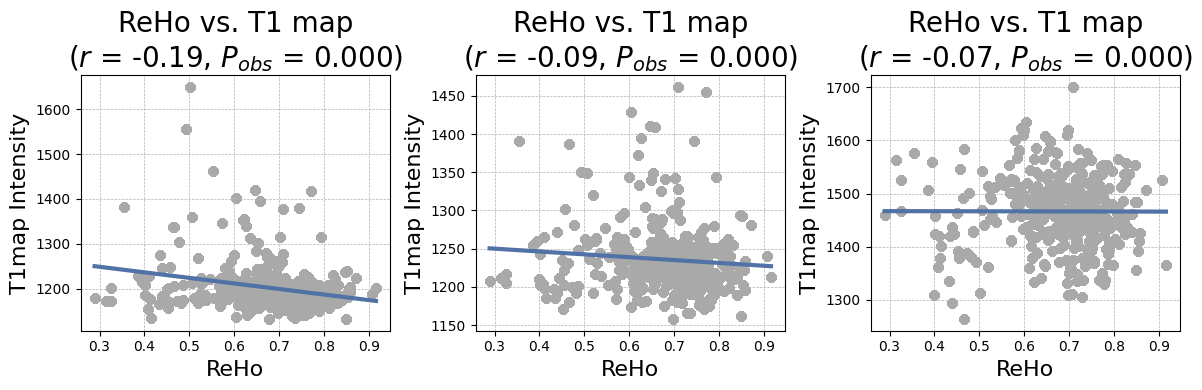

In [6]:
plot_reho_swm_correlation(sub_id="03", qmri="T1map")

## Graph

In [454]:
# Combine left and right hemisphere data
rfile = glob.glob(f"/host/verges/tank/data/youngeun/ReHo/neighbors1/fsLR32k_schaefer400/sub-PNC019_ses-03_surf-fsLR-32k_desc-ReHo.shape.gii")[0]
reho = nb.load(rfile).darrays[0].data
reho_sq = np.squeeze(reho)

# Map parcellated data to the surface
reho_dc = parcel_to_surface(reho_sq, 'schaefer_400_conte69')

In [455]:
reho_dc

array([0.68116999, 0.61250001, 0.63042003, ..., 0.49797001, 0.49797001,
       0.49797001])

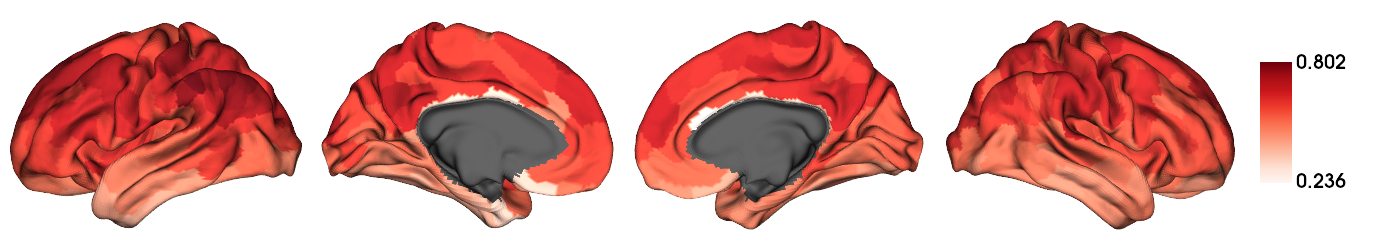

In [461]:
# Map parcellated data to the surface
reho_dc[mask_32k == False] = np.nan

plot_hemispheres(f32k_lh, f32k_rh, reho_dc, cmap='Reds', nan_color=(0.3, 0.3, 0.3, 1),
                      zoom=1.5, size=(1400, 250), embed_nb=True,
                      color_bar='right', cb__labelTextProperty={"fontSize": 20})

/tmp/ipykernel_1255583/2520148629.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/tmp/ipykernel_1255583/2520148629.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


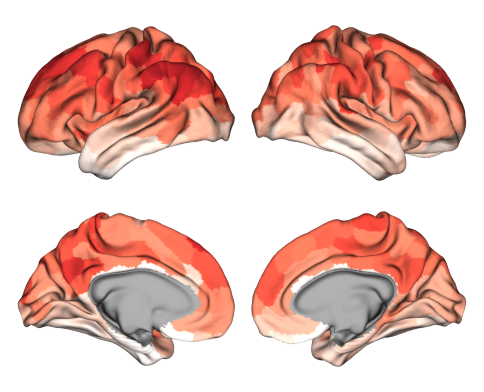

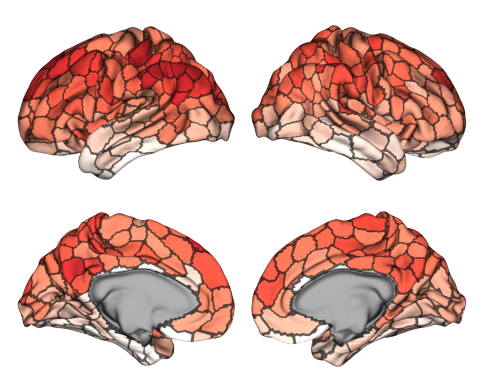

In [487]:
surfaces = fetch_fslr()
p = Plot(f32k_lh, f32k_rh)

# add schaefer parcellation (no color bar needed)
left = reho_dc[:len(reho_dc)//2]
right = reho_dc[len(reho_dc)//2:]
p.add_layer({'left': left, 'right': right}, cbar=False, cmap='Reds', color_range=(0.4, 0.85))

fig = p.build()
fig.show()

p.add_layer({'left': left, 'right': right}, cmap='Greys',
            as_outline=True, cbar=False, alpha=0.7)
fig = p.build()
fig.show()

### T1map

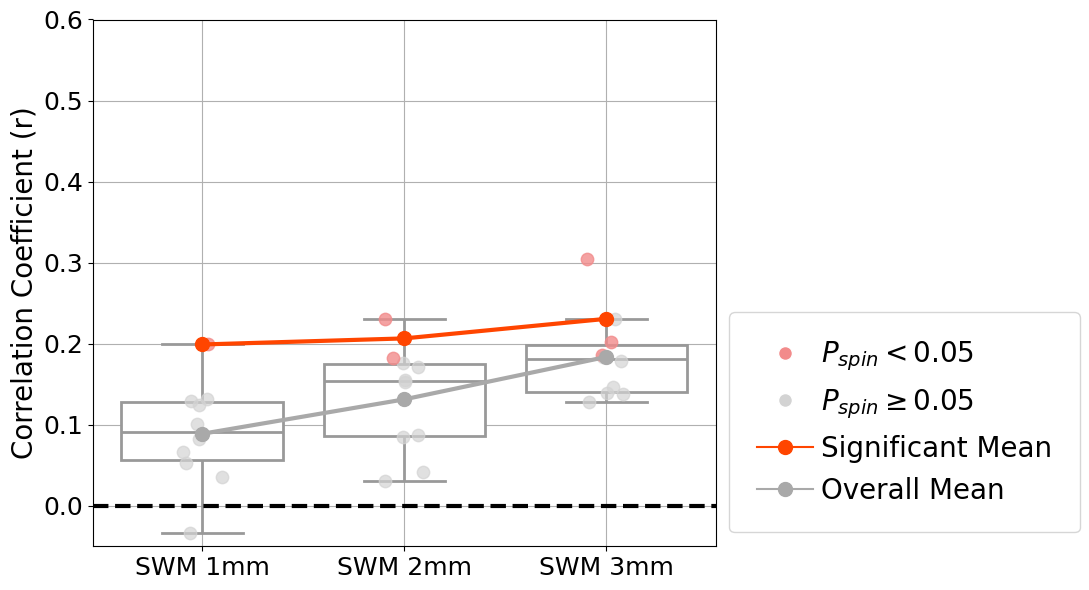

In [520]:
swm_1mm = [0.101, 0.035, 0.066, 0.129, -0.033, 0.053, 0.199, 0.124, 0.132, 0.082]
swm_2mm = [0.171, 0.042, 0.087, 0.182, 0.031, 0.085, 0.231, 0.155, 0.153, 0.176]
swm_3mm = [0.186, 0.138, 0.128, 0.202, 0.139, 0.146, 0.184, 0.179, 0.231, 0.304]
p_1mm = [0.577, 0.878, 0.777, 0.241, 0.904, 0.796, 0.046, 0.298, 0.142, 0.603]
p_2mm = [0.188, 0.869, 0.694, 0.049, 0.886, 0.661, 0.028, 0.12, 0.068, 0.111]
p_3mm = [0.03, 0.362, 0.433, 0.046, 0.32, 0.213, 0.051, 0.098, 0.052, 0]

plot_swm_boxplot(swm_1mm, swm_2mm, swm_3mm, p_1mm, p_2mm, p_3mm, significant_color="#F28B8B", highlight_color="#FF4500")

### MTSAT

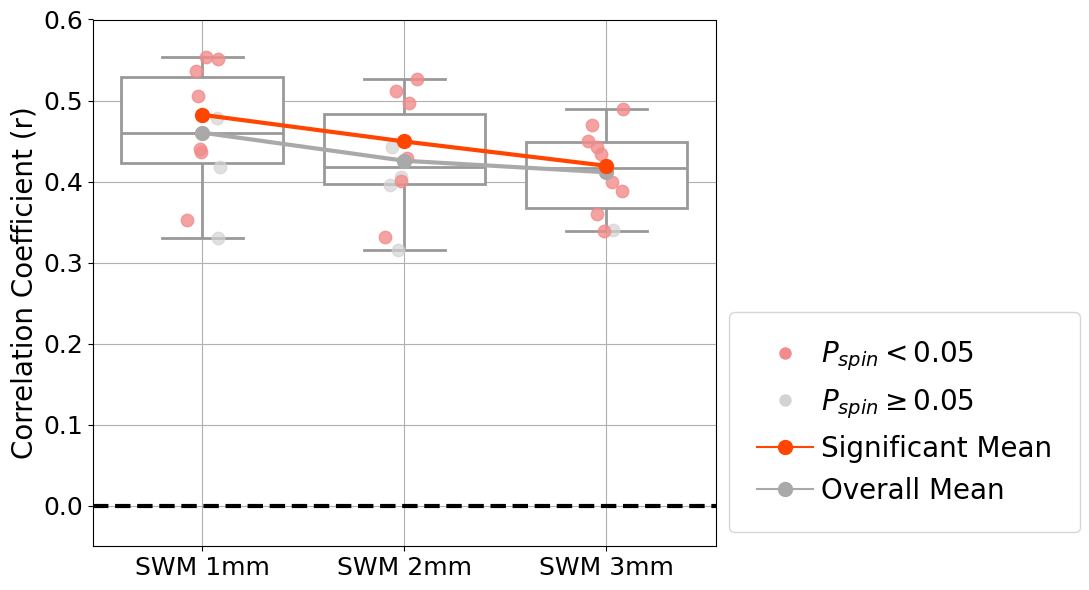

In [521]:
swm_1mm = [0.44, 0.437, 0.554, 0.418, 0.551, 0.479, 0.33, 0.506, 0.536, 0.353]
swm_2mm = [0.396, 0.401, 0.526, 0.406, 0.512, 0.443, 0.315, 0.429, 0.497, 0.332]
swm_3mm = [0.443, 0.45, 0.47, 0.434, 0.49, 0.34, 0.389, 0.36, 0.339, 0.4]
p_1mm = [0.048, 0.033, 0.001, 0.108, 0, 0.076, 0.126, 0, 0.016, 0.008]
p_2mm = [0.057, 0.037, 0.005, 0.068, 0, 0.11, 0.108, 0, 0.007, 0.021]
p_3mm = [0.001, 0.001, 0.017, 0.015, 0, 0.17, 0, 0, 0.032, 0.013]

plot_swm_boxplot(swm_1mm, swm_2mm, swm_3mm, p_1mm, p_2mm, p_3mm, significant_color="#F28B8B", highlight_color="#FF4500")

### Mean value (group study)

In [118]:
# Subject IDs 및 qMRI 설정
sub_ids = ["03", "06", "07", "09", "10", "15", "16", "18", "19", "22"]

# 데이터를 저장할 리스트
reho_stack = []

for sub_id in sub_ids:

    rfile_path = glob.glob(f"/host/verges/tank/data/youngeun/ReHo/neighbors1/fsLR32k_schaefer400/sub-PNC0{sub_id}_ses-03_surf-fsLR-32k_desc-ReHo.shape.gii")
    reho_data = nb.load(rfile_path[0]).darrays[0].data

    reho_stack.append(reho_data)

reho_schaefer400_10sub = np.mean(reho_stack, axis=0)
reho_schaefer400_mean = parcel_to_surface(reho_schaefer400_10sub, 'schaefer_400_conte69')

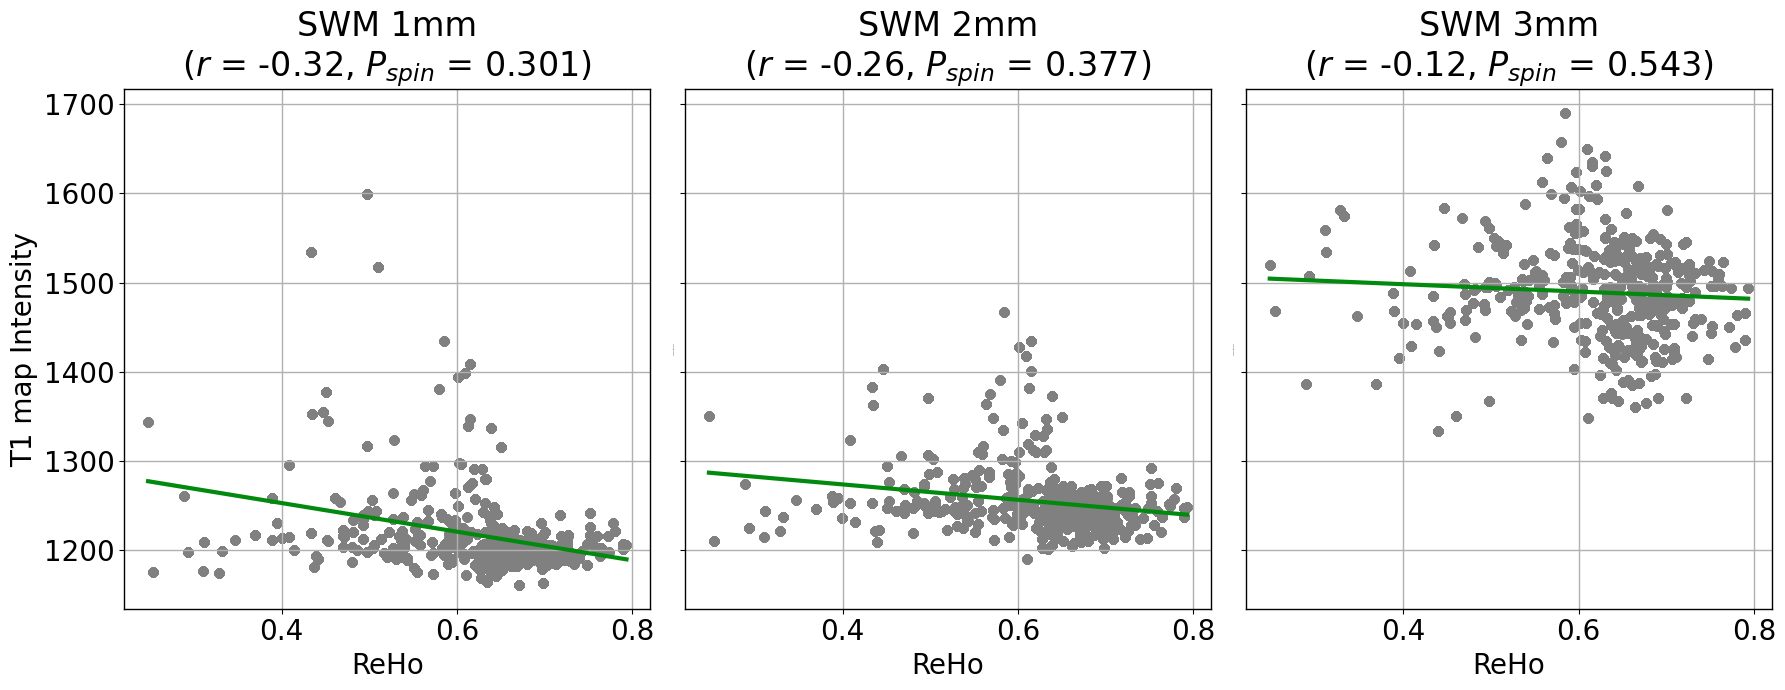

In [127]:
# List of mod2 datasets and their titles
#qmri_list = [T1map_swm_1mm, T1map_swm_2mm, T1map_swm_3mm]
qmri_list = [T1map_schaefer400_swm1mm, T1map_schaefer400_swm2mm, T1map_schaefer400_swm3mm]
titles = ['SWM 1mm', 'SWM 2mm', 'SWM 3mm']

fdata_L = reho_schaefer400_mean[0:int(N32k/2)]
fdata_R = reho_schaefer400_mean[int(N32k/2):N32k]

# Spin permutation on full data (Get the rotated data)
func_rotated = np.hstack(spinp.randomize(fdata_L, fdata_R))

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharex=True, sharey=True)

# Loop through mod2 datasets and plot
for i, (qmri, title) in enumerate(zip(qmri_list, titles)):

    # Filter valid data
    valid_indices = ~np.isnan(reho_schaefer400_mean) & ~np.isnan(qmri)
    valid_func = reho_schaefer400_mean[valid_indices]
    valid_qmri = qmri[valid_indices]

    non_zero_mask = ~((valid_func == 0) & (valid_qmri == 0))
    valid_fc = valid_func[non_zero_mask]
    valid_swm = valid_qmri[non_zero_mask]

    # Observed correlation
    r_obs, p_obs = spearmanr(valid_fc, valid_swm)
    
    # Permutation-based correlations
    r_spin = np.array([spearmanr(perm[valid_indices][non_zero_mask], valid_swm)[0] for perm in func_rotated])
    p_spin = np.mean(np.abs(r_spin) >= np.abs(r_obs))
    
    # Create DataFrame for seaborn
    df = pd.DataFrame({'FS': valid_fc, 'qMRI': valid_swm})

    # Scatter plot with linear regression
    sns.regplot(
        x='FS', y='qMRI', data=df, ax=axes[i],
        scatter_kws={'color': 'grey', 'alpha': 0.6}, line_kws={'color': '#028A0F', 'linewidth': 3}
    )

    # Set labels and title
    axes[i].set_title(f'{title}\n$(r$ = {r_obs:.2f}, $P_{{spin}}$ = {p_spin:.3f})', fontsize=24)
    axes[i].set_xlabel('ReHo', fontsize=20)
    axes[i].set_ylabel('T1 map Intensity', fontsize=20 if i == 0 else 0)  # Only first subplot has y-label
    axes[i].tick_params(axis='both', labelsize=20)
    
    # Make outer grid lines thicker and set inner grid lines as thinner
    axes[i].grid(True, which='both', axis='both', linestyle='-', linewidth=1)  # Thin grid lines for the inner grid
    # Make outer borders thicker
    for spine in axes[i].spines.values():
        spine.set_linewidth(1)
        spine.set_edgecolor('black')

# Adjust layout
plt.tight_layout()
plt.show()

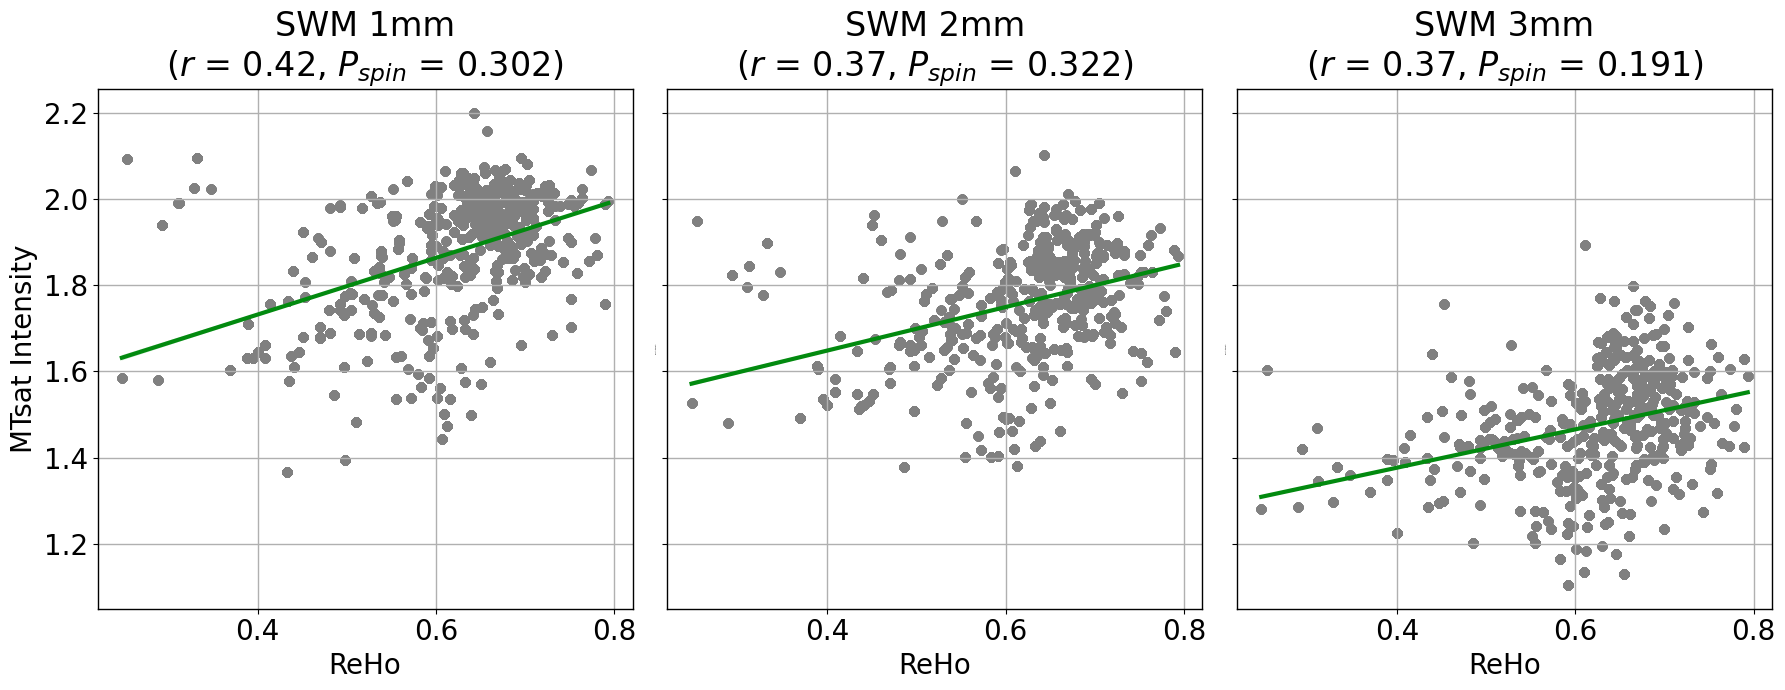

In [122]:
# List of mod2 datasets and their titles
#qmri_list = [T1map_swm_1mm, T1map_swm_2mm, T1map_swm_3mm]
qmri_list = [MTSAT_schaefer400_swm1mm, MTSAT_schaefer400_swm2mm, MTSAT_schaefer400_swm3mm]
titles = ['SWM 1mm', 'SWM 2mm', 'SWM 3mm']

fdata_L = reho_schaefer400_mean[0:int(N32k/2)]
fdata_R = reho_schaefer400_mean[int(N32k/2):N32k]

# Spin permutation on full data (Get the rotated data)
func_rotated = np.hstack(spinp.randomize(fdata_L, fdata_R))

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharex=True, sharey=True)

# Loop through mod2 datasets and plot
for i, (qmri, title) in enumerate(zip(qmri_list, titles)):

    # Filter valid data
    valid_indices = ~np.isnan(reho_schaefer400_mean) & ~np.isnan(qmri)
    valid_func = reho_schaefer400_mean[valid_indices]
    valid_qmri = qmri[valid_indices]

    non_zero_mask = ~((valid_func == 0) & (valid_qmri == 0))
    valid_fc = valid_func[non_zero_mask]
    valid_swm = valid_qmri[non_zero_mask]

    # Observed correlation
    r_obs, p_obs = spearmanr(valid_fc, valid_swm)
    
    # Permutation-based correlations
    r_spin = np.array([spearmanr(perm[valid_indices][non_zero_mask], valid_swm)[0] for perm in func_rotated])
    p_spin = np.mean(np.abs(r_spin) >= np.abs(r_obs))
    
    # Create DataFrame for seaborn
    df = pd.DataFrame({'FS': valid_fc, 'qMRI': valid_swm})

    # Scatter plot with linear regression
    sns.regplot(
        x='FS', y='qMRI', data=df, ax=axes[i],
        scatter_kws={'color': 'grey', 'alpha': 0.6}, line_kws={'color': '#028A0F', 'linewidth': 3}
    )

    # Set labels and title
    axes[i].set_title(f'{title}\n$(r$ = {r_obs:.2f}, $P_{{spin}}$ = {p_spin:.3f})', fontsize=24)
    axes[i].set_xlabel('ReHo', fontsize=20)
    axes[i].set_ylabel('MTsat Intensity', fontsize=20 if i == 0 else 0)  # Only first subplot has y-label
    axes[i].tick_params(axis='both', labelsize=20)
    
    # Make outer grid lines thicker and set inner grid lines as thinner
    axes[i].grid(True, which='both', axis='both', linestyle='-', linewidth=1)  # Thin grid lines for the inner grid
    # Make outer borders thicker
    for spine in axes[i].spines.values():
        spine.set_linewidth(1)
        spine.set_edgecolor('black')

# Adjust layout
plt.tight_layout()
plt.show()